# EPI DTI, part 2 — simulate, reconstruct, quantify

The three `.seq` files from `01_build.ipynb`, played against a numerical phantom and taken through to
an ADC map. Nothing here knows it is a simulation: `data` is `(n_coils, n_samples)`, and on the
scanner the same call takes the same array out of a twix reader.

**No unwarping step appears anywhere.** EPI distortion is the `exp(-2πi·df·t)` term in the encoding
operator, so putting the field map *into* the operator and solving removes it — the same operator, and
the same code, that deblurs a spiral. What differs between the two readouts is only where the echo
sits in the sample times and which density compensation applies, and both are read from the sidecar
rather than assumed.

In [1]:
%matplotlib inline
import math
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

sys.path.insert(0, str(Path('../lib').resolve()))

import seqcraft as sc
from mr0_bridge import phantom_with_diffusion, simulate, to_mr0
from noncartesian_recon import Readout, reconstruct_shot, reconstruct_volume

warnings.filterwarnings('ignore')
# Every image here is 128 x 128, so the default 100 dpi upsamples it three and a half times and
# spends half a megabyte of committed notebook doing it.  72 dpi shows the same pixels.
plt.rcParams['figure.dpi'] = 72
print('seqcraft', sc.__version__)

D:\MIniconda\envs\NUM\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


D:\MIniconda\envs\NUM\Lib\site-packages\sigpy\config.py:27: UserWarning: Importing cupy.cuda.cudnn failed. For more details, see the error stack below:
DLL load failed while importing cudnn: The specified module could not be found.
  warnings.warn(


seqcraft 0.3.0


## 1. The three sequences, and a phantom to play them against

In [2]:
SEQ_DIR = Path('seq')
REGIME = 'epi'
system = (sc.System.preset('cima_x')
          .derate(REGIME, grad=0.85, slew=1.00)
          .derate('diffusion', grad=0.85, slew=0.30))

scans = {}
for path in sorted(SEQ_DIR.glob('epi_dwi_*shot_*.traj.npz')):
    n_shots = int(path.name.split('_')[2].removesuffix('shot'))
    played = pp.Sequence(system=system.limits(REGIME))
    played.read(str(path.with_suffix('').with_suffix('.seq')))
    with np.load(path) as extra:
        scans[n_shots] = {
            'seq': played,
            'readout': Readout.from_sidecar(path),
            'te': float(extra['te_s']),
            'tr': float(extra['tr_s']),
            'b': float(extra['achieved_b_values'][-1]),
            'direction': tuple(float(v) for v in extra['directions'][0]),
            'echo_spacing': float(extra['echo_spacing_s']),
            'pe_bandwidth_hz': float(extra['pe_bandwidth_hz']),
            'n_echoes': int(extra['n_echoes']),
            'samples_per_echo': int(extra['samples_per_echo']),
            'lines': np.asarray(extra['lines'], dtype=int),
            'partial_fourier_pe': float(extra['partial_fourier_pe']),
        }

b0_seq = pp.Sequence(system=system.limits(REGIME))
b0_seq.read(str(next(SEQ_DIR.glob('b0map_*.seq'))))
with np.load(next(SEQ_DIR.glob('b0map_*.meta.npz'))) as meta_npz:
    B0_TE_S = tuple(float(v) for v in meta_npz['te_s'])
    B0_DTE = float(meta_npz['delta_te_s'])
    B0_MATRIX = int(meta_npz['matrix'])
    B0_LINES = np.asarray(meta_npz['lines'], dtype=int)
    B0_POLARITY = tuple(int(v) for v in meta_npz['polarity'])

one = scans[1]
MATRIX = one['readout'].matrix
FOV_M = one['readout'].fov_m
SLICE_MM = 4.0
# MRzero materialises a samples x voxels array, so this is bounded by memory rather than patience.
PHANTOM_N = 128
N_COILS = 8
D_TRUE = 1.5           # 1e-3 mm^2/s

for n, scan in scans.items():
    ro = scan['readout']
    print(f'{n} shot   {MATRIX}x{MATRIX}, {ro.n_interleaves} x {ro.n_samples} samples, '
          f'{scan["n_echoes"]} echoes of {scan["echo_spacing"] * 1e6:.0f} us, '
          f'TE {scan["te"] * 1e3:.2f} ms, PE bandwidth {scan["pe_bandwidth_hz"]:.2f} Hz/px')
print(f'field map {B0_MATRIX}x{B0_MATRIX}, TE {B0_TE_S[0] * 1e3:.2f} / {B0_TE_S[1] * 1e3:.2f} ms, '
      f'unambiguous +-{1 / (2 * B0_DTE):.0f} Hz')
print(f'sample times run {one["readout"].t_adc_s.min() * 1e3:+.2f} .. '
      f'{one["readout"].t_adc_s.max() * 1e3:+.2f} ms about the echo, which is what a mid-train echo '
      f'looks like')

1 shot   128x128, 1 x 21888 samples, 96 echoes of 520 us, TE 59.40 ms, PE bandwidth 20.03 Hz/px
2 shot   128x128, 2 x 10560 samples, 48 echoes of 520 us, TE 42.80 ms, PE bandwidth 40.06 Hz/px
field map 128x128, TE 4.00 / 6.38 ms, unambiguous +-210 Hz
sample times run -16.87 .. +32.99 ms about the echo, which is what a mid-train echo looks like


In [3]:
axis = (np.arange(PHANTOM_N) - PHANTOM_N / 2) / PHANTOM_N
grid_y, grid_x = np.meshgrid(axis, axis, indexing='ij')      # every map here is [y, x]
# Stronger than the spiral example's field, and deliberately: at 20 Hz per pixel the spiral's
# +-60 Hz would displace by three pixels, which is not enough to see.  Kept inside the field map's
# own +-210 Hz unambiguous range, since a map that wraps is a different demonstration.
b0_truth = (150.0 * grid_x
            + 120.0 * np.exp(-((grid_x - 0.18) ** 2 + (grid_y + 0.10) ** 2) / (2 * 0.07 ** 2))
            ).astype(np.float32)

phantom, maps = phantom_with_diffusion(
    size_m=(FOV_M, FOV_M, SLICE_MM / 1e3), matrix=PHANTOM_N, d_1e_3_mm2_s=D_TRUE,
    b0_hz=b0_truth, shape='blobs', n_coils=N_COILS)


def on_grid(field, matrix):
    '''Resample a map onto a square grid of any size, by linear interpolation.

    Nearest neighbour looks equivalent and is not: at a non-integer grid ratio it duplicates and
    skips rows, and a B0 map with that pattern in it puts a periodic phase error into the correction.
    '''
    array = np.asarray(field)
    if np.iscomplexobj(array):
        return (on_grid(array.real, matrix) + 1j * on_grid(array.imag, matrix)).astype(np.complex64)
    source = (np.arange(array.shape[-1]) - array.shape[-1] / 2) / array.shape[-1]
    target = (np.arange(matrix) - matrix / 2) / matrix
    rows = np.apply_along_axis(lambda line: np.interp(target, source, line), -1,
                              array.astype(np.float64))
    return np.apply_along_axis(lambda line: np.interp(target, source, line), -2, rows)


span = float(b0_truth.max() - b0_truth.min())
print(f'{int((maps["PD"] > 0).sum())} voxels on {PHANTOM_N}x{PHANTOM_N}, {N_COILS} channels')
print(f'D present {sorted(set(np.round(maps["D"][maps["PD"] > 0], 3)))} e-3 mm2/s')
print(f'B0 {b0_truth.min():.0f} .. {b0_truth.max():.0f} Hz')
for n, scan in scans.items():
    print(f'  {n} shot: up to '
          f'{np.abs(b0_truth).max() / scan["pe_bandwidth_hz"]:.1f} pixels of displacement, '
          f'and {span / scan["pe_bandwidth_hz"]:.1f} pixels of *differential* stretch across the FOV')

9085 voxels on 128x128, 8 channels
D present [np.float32(0.375), np.float32(1.5), np.float32(3.75)] e-3 mm2/s
B0 -75 .. 147 Hz
  1 shot: up to 7.4 pixels of displacement, and 11.1 pixels of *differential* stretch across the FOV
  2 shot: up to 3.7 pixels of displacement, and 5.6 pixels of *differential* stretch across the FOV


## 2. The field map

Reconstructed from its own two echoes, exactly as the spiral example does it: the phase difference
between echoes divided by `2π·ΔTE`. `angle(echo0 · conj(echo1))` gives **+Δf**, because the signal
accumulates `exp(-2πi·Δf·t)` and the later echo therefore lags. The other way round returns a map of
the right shape and range and the wrong sign, and the correction then adds the distortion it should
remove.

In [4]:
b0_mr0, b0_meta = to_mr0(b0_seq, system=system, event_dt_s=500e-6)
b0_signal = simulate(b0_mr0, phantom)
acquiring = [rep for rep in range(b0_meta.n_reps) if b0_meta.samples_of_rep(rep).size]
per_echo = b0_meta.samples_of_rep(acquiring[0]).size // len(B0_TE_S)
print(f'{len(acquiring)} acquiring repetitions of {b0_meta.n_reps}, {per_echo} samples per echo')

echoes = []
for echo, polarity in enumerate(B0_POLARITY):
    kspace = np.zeros((B0_MATRIX, B0_MATRIX), dtype=complex)
    for row, line in enumerate(B0_LINES):
        samples = b0_meta.samples_of_rep(acquiring[row])[echo * per_echo:(echo + 1) * per_echo]
        kspace[line] = b0_signal[samples, 0][::polarity]
    echoes.append(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace))))

field_measured = np.angle(echoes[0] * np.conj(echoes[1])) / (2 * np.pi * B0_DTE)
support = np.abs(echoes[0]) > 0.1 * np.abs(echoes[0]).max()
field_measured = np.where(support, field_measured, 0.0).astype(np.float32)

truth_on_b0 = on_grid(b0_truth, B0_MATRIX)
error = field_measured[support] - truth_on_b0[support]
print(f'measured field {field_measured[support].min():+.0f} .. '
      f'{field_measured[support].max():+.0f} Hz')
print(f'  versus the truth: mean error {error.mean():+.2f} Hz, '
      f'RMS {np.sqrt((error ** 2).mean()):.2f} Hz over {int(support.sum())} pixels')
print(f'  {np.sqrt((error ** 2).mean()) / scans[1]["pe_bandwidth_hz"]:.3f} pixels of residual '
      f'displacement, which is what the map error costs the single-shot image')

128 acquiring repetitions of 188, 128 samples per echo
measured field -76 .. +154 Hz
  versus the truth: mean error +0.00 Hz, RMS 2.58 Hz over 9100 pixels
  0.129 pixels of residual displacement, which is what the map error costs the single-shot image


## 3. Simulate the diffusion scans

One shot at a time. MRzero materialises a samples × voxels array, and a 2 s TR with a spoiler makes
the shots independent, so taking them one at a time is exact rather than an approximation.

`k_reference='excitation'` on the bridge: k accumulates from the excitation and its sign flips at the
refocusing pulse, which is the physical convention and what `calculate_kspacePP` computes. Measuring
from each shot's first ADC sample instead — right for a spiral, whose sampling begins at k=0 — would
subtract this readout's own prephaser away and report a trajectory starting at the origin rather than
at the corner of k-space.

The cross-check at the end of the cell is the one that matters, and it caught two real faults in the
bridge. Both were invisible on a spiral and produced a **Nyquist ghost** here, because an EPI readout
reverses every echo and so turns any systematic sample-placement error into one that alternates sign.

In [5]:
SHOT_REPS = 3          # fat sat + excitation + refocusing, per shot in the file
SKIP_FAT_SAT = 1       # ... but the fat sat is not simulated: MRzero's pulses are ideal rotations,
                       # so a -419 Hz fat-sat pulse would simulate as an on-resonance 90 that
                       # saturates *water*, and its z-only spoiler is invisible to a 2D phantom.
field = on_grid(field_measured, MATRIX).astype(np.float32)
sens = on_grid(maps['coil_sens'], MATRIX)


def acquire(seq, shot):
    '''Simulate one shot of a played file: (n_coils, n_samples).'''
    mr0_seq, meta = to_mr0(seq, system=system, event_dt_s=200e-6,
                           first_rep=shot * SHOT_REPS + SKIP_FAT_SAT,
                           max_reps=SHOT_REPS - SKIP_FAT_SAT,
                           k_reference='excitation')
    signal = simulate(mr0_seq, phantom)
    chosen = meta.samples_of_rep(int(np.unique(meta.adc_rep)[0]))
    return signal[chosen, :].T, meta


# Volume 0 is b = 0; volume 1 is the first direction.  The file acquires every shot of a volume before
# moving on, so volume v shot s is shot v * n_shots + s -- the SET and SEG labels on real data.
raw, metas = {}, {}
for n, scan in scans.items():
    raw[n] = {}
    for volume, name in enumerate(('b0', 'weighted')):
        acquired = [acquire(scan['seq'], volume * n + s) for s in range(n)]
        raw[n][name] = [signal for signal, _ in acquired]
        # Keep the first shot's metadata rather than simulating again for it below: a second
        # `acquire` call is a whole extra simulation, and on a 21 888-sample shot that is not free.
        metas.setdefault(n, acquired[0][1])
    print(f'{n} shot: {len(raw[n]["b0"])} shots x {raw[n]["b0"][0].shape} per volume')

# The simulator's own trajectory against the module's.  This is the check that decides whether a
# reconstruction can work at all: the data is placed in k-space by one of them and read out of it by
# the other, and any disagreement is an artefact with no other explanation.
probe_meta = metas[1]
ro_one = scans[1]['readout']
bridge_k = probe_meta.kspace_per_m[:2, :ro_one.n_samples]
dk = 1e3 / (FOV_M * 1e3)
mismatch = bridge_k - ro_one.k_per_m[0]
per_echo = mismatch[0].reshape(scans[1]['n_echoes'], scans[1]['samples_per_echo']).mean(axis=1)
print(f'simulator vs sidecar trajectory: worst {np.abs(mismatch).max() / dk:.5f} dk')
print(f'  alternating component (even echoes minus odd) '
      f'{abs(per_echo[::2].mean() - per_echo[1::2].mean()) / dk:.5f} dk')
print()
print('That second number is the one to watch on an EPI train.  A *constant* k offset is a linear')
print('phase across the image and nothing worse; an offset that alternates echo to echo is a phase')
print('ramp of alternating sign, which is a Nyquist ghost at half the FOV.  So a sample-placement')
print('error a spiral would merely blur with, EPI turns into stripes -- which is also exactly what')
print('an uncalibrated gradient delay does on a real scanner, and why it must be measured there.')

1 shot: 1 shots x (8, 21888) per volume


2 shot: 2 shots x (8, 10560) per volume
simulator vs sidecar trajectory: worst 0.00011 dk
  alternating component (even echoes minus odd) 0.00000 dk

That second number is the one to watch on an EPI train.  A *constant* k offset is a linear
phase across the image and nothing worse; an offset that alternates echo to echo is a phase
ramp of alternating sign, which is a Nyquist ghost at half the FOV.  So a sample-placement
error a spiral would merely blur with, EPI turns into stripes -- which is also exactly what
an uncalibrated gradient delay does on a real scanner, and why it must be measured there.


## 4. Reconstruct, with and without the field map

The uncorrected image is the interesting one: the distortion is **geometric**, a stretch along the
phase-encode direction rather than a blur, and it is worst where the field is furthest from its mean.

### What this costs, and why it costs it

Measured on this notebook: the whole thing runs in **300 s**, of which `simulate` is 3.6 s a shot and a single corrected solve is **37 s**. The
reconstruction dominates by an order of magnitude, and one number explains it —
`segments_for` returns **88** here against **13** for the spiral example.

The segmented operator does `segments × n_coils` oversampled FFTs per application, and the segment
count scales with `field range × readout span`. EPI loses on both: a 49.9 ms train against the
spiral's 17.1 ms, and a field deliberately widened to 217 Hz so the displacement is 7 pixels rather
than 3. Neither is avoidable if the notebook is to show what it claims to show. Without the field map
the operator needs the floor of 8 segments and the same solve takes 5.7 s, which is why the
uncorrected images are nearly free.

So the levers, in the order they are worth pulling: **do not correct what you are not studying** (the
density-compensation section below runs at `b0 = 0`, which is both 8× faster and the correct
isolation); **do not solve twice for the same thing**; and only then reduce iterations, which trades
accuracy for time and is the one that costs you something.

In [6]:
ITERATIONS = 30

images, uncorrected = {}, {}
for n, scan in scans.items():
    ro = scan['readout']
    images[n], uncorrected[n] = {}, {}
    for name, shots in raw[n].items():
        common = {'sens': sens, 'iterations': ITERATIONS, 'dcf': 'speed'}
        if n == 1:
            images[n][name] = reconstruct_shot(shots[0], ro, b0_hz=field, **common)
            uncorrected[n][name] = reconstruct_shot(shots[0], ro, b0_hz=0.0, **common)
        else:
            # Pooled, not averaged: alone each shot covers every other ky line and is aliased, and
            # averaging two aliased images keeps the aliasing.
            images[n][name] = reconstruct_volume(shots, ro, b0_hz=field, **common)
            uncorrected[n][name] = reconstruct_volume(shots, ro, b0_hz=0.0, **common)
    print(f'{n} shot reconstructed at {MATRIX}x{MATRIX} from {n} x {ro.n_samples} samples '
          f'x {N_COILS} channels')

1 shot reconstructed at 128x128 from 1 x 21888 samples x 8 channels


2 shot reconstructed at 128x128 from 2 x 10560 samples x 8 channels


## 5. Two things the spiral reconstruction had wired in

Both were correct for a spiral for the same reason — a spiral starts at k = 0 — and both are wrong
here. Both are worth *measuring* rather than asserting, and doing so is what showed that neither costs
what one would guess: the density compensation matters to a single back-projection and much less to a
converged solve, and a wrong echo reference leaves the magnitude image untouched exactly.

The density-compensation table below also settles which of the two wrong answers is worse. Weighting by
`|k|` is not merely suboptimal for this trajectory but *actively* wrong -- 17 times the error of the true
Jacobian for a single back-projection -- while weighting by **nothing at all** comes within a few percent
of it, because an EPI line is close to uniformly spaced in k except at its two ends. A radial
argument applied to a Cartesian-ish trajectory is worse than no argument.

In [7]:
ro = scans[1]['readout']


def relative_rmse(image, reference):
    '''Scale-invariant RMSE of one magnitude image against another.

    The single best scale factor is fitted and divided out first.  Without that the comparison is
    dominated by overall brightness -- which differs between a back-projection and a solve, and
    between density compensations, for reasons that have nothing to do with image quality.
    '''
    got, want = np.abs(image).ravel(), np.abs(reference).ravel()
    scale = float(got @ want) / float(got @ got) if got @ got else 0.0
    return float(np.sqrt(np.mean((scale * got - want) ** 2)) / np.sqrt(np.mean(want ** 2)))


# Deliberately **without** the field map, which is both the right isolation and 8x faster.
#
# A density compensation is a property of the *trajectory* -- how fast k moves, and therefore how
# densely the samples land -- and has nothing to do with off-resonance.  Including the field map here
# would confound the two and let a reader attribute one effect to the other; it would also raise the
# operator from 8 time segments to 88, which is 37 s per solve rather than 6, and this cell needs five
# of them.  The corrected reconstructions are in section 4; this is a separate question.
NO_FIELD = 0.0

# A well-converged solve to compare against, rather than the phantom: every reconstruction here also
# carries T2 decay across a 50 ms readout and the coil weighting, so measuring against proton density
# would report those as errors too.  Comparing structured residuals against a reference is the advice
# `segments_for` gives for the same reason.  All three weightings solve the same normal equations --
# a density compensation preconditions them, it does not change their solution -- so one reference
# serves all three.
converged = reconstruct_shot(raw[1]['b0'][0], ro, b0_hz=NO_FIELD, sens=sens,
                             iterations=200, dcf='speed')


# (a) Density compensation.  |k| is the spiral's Jacobian; a ramp-sampled EPI line crosses k = 0 at
# full gradient, which is where its samples are *sparsest*, so |k| weights this trajectory backwards.
#
# Measured two ways on purpose.  One adjoint -- a single density-compensated back-projection, which is
# what gridding does -- is where the Jacobian has to be right, because nothing downstream can repair
# it.  A converged conjugate-gradient solve is a different matter: the weights there act as a
# preconditioner on a problem whose *solution* they do not change, so a wrong one costs iterations
# rather than accuracy.  Conflating the two is how "the density compensation barely matters" and "the
# density compensation is critical" are both repeated, each true of one case.
variants, adjoints = {}, {}
for label, dcf in (('speed  |dk/dt|', 'speed'), ('radial |k|', 'radial'), ('none', 'none')):
    variants[label] = reconstruct_shot(
        raw[1]['b0'][0], ro, b0_hz=NO_FIELD, sens=sens, iterations=ITERATIONS, dcf=dcf)
    adjoints[label] = reconstruct_shot(
        raw[1]['b0'][0], ro, b0_hz=NO_FIELD, sens=sens, iterations=1, dcf=dcf)

print(f'{"density compensation":>22}  {"1 adjoint":>10}  {f"{ITERATIONS} CG":>8}   '
      f'(relative RMSE against a 200-iteration solve)')
for label in variants:
    print(f'{label:>22}  {relative_rmse(adjoints[label], converged):>10.4f}  '
          f'{relative_rmse(variants[label], converged):>8.4f}')
print()
print('The Jacobian is what a single back-projection depends on, and |k| is the wrong one for this')
print('trajectory.  Thirty iterations close most of the gap -- so on EPI the cost of getting it')
print('wrong is paid in convergence rather than in accuracy, and the reason to pass dcf="speed" is')
print('that it is the true Jacobian, not that the picture is otherwise unusable.')

  density compensation   1 adjoint     30 CG   (relative RMSE against a 200-iteration solve)
        speed  |dk/dt|      0.0521    0.0384
            radial |k|      0.9062    0.1561
                  none      0.0928    0.0393

The Jacobian is what a single back-projection depends on, and |k| is the wrong one for this
trajectory.  Thirty iterations close most of the gap -- so on EPI the cost of getting it
wrong is paid in convergence rather than in accuracy, and the reason to pass dcf="speed" is
that it is the true Jacobian, not that the picture is otherwise unusable.


In [8]:
# (b) The echo reference.  Rebasing the sample times on the first sample -- which is what inferring
# the echo from min(t) does -- shifts every time by `time_to_echo`, and shifting t by a constant D
# multiplies the operator by diag(exp(-2i pi df(r) D)).  So the solution comes back multiplied by
# exp(+2i pi df(r) D): a *spatially varying phase* on the image, and the magnitude is untouched.
#
# Which is worth being precise about rather than hand-waving as "an artefact".  For a magnitude image
# or an ADC map it costs nothing.  It is fatal for anything that reads the phase -- a field map, flow,
# and the phase navigators multi-shot DWI needs to make its shots mutually coherent.
shifted = Readout(
    k_per_m=ro.k_per_m,
    t_adc_s=ro.t_adc_s - ro.t_adc_s.min(),      # as if the first sample were the echo
    fov_m=ro.fov_m, matrix=ro.matrix, t_echo_s=0.0,
)
wrong = reconstruct_shot(raw[1]['b0'][0], shifted, b0_hz=field, sens=sens,
                         iterations=ITERATIONS, dcf='speed')
right = images[1]['b0']
lead = float(ro.t_adc_s.min())
support = np.abs(right) > 0.15 * np.abs(right).max()
magnitude_rmse = float(
    np.sqrt(np.mean((np.abs(wrong) - np.abs(right)) ** 2)) / np.abs(right).max())
observed = np.angle(wrong * np.conj(right))[support]
# The prediction has to be compared *wrapped*, since `angle` returns (-pi, pi]: over a 217 Hz field
# and 16.87 ms the true phase spans three and a half cycles, so an unwrapped comparison would report
# a peak-to-peak of one cycle no matter what and prove nothing.
predicted = 2 * np.pi * field[support] * abs(lead)
residual = np.angle(np.exp(1j * (observed - (predicted - predicted.mean()))))
print(f'the first sample is {lead * 1e3:.2f} ms before the echo, and the field spans '
      f'{np.ptp(field[support]):.0f} Hz')
print(f'  predicted phase error, 2 pi df D   {np.ptp(predicted) / (2 * np.pi):.2f} cycles '
      f'peak-to-peak')
print(f'  observed, against that prediction  {np.std(residual) / (2 * np.pi):.4f} cycles RMS '
      f'residual (wrapped)')
print(f'  magnitude RMSE                     {magnitude_rmse:.6f}   -- zero, by the algebra above')
print()
print('And a sidecar reporting *absolute* times -- which would carry TE into the off-resonance term,')
print('three and a half cycles here -- is refused outright rather than quietly reconstructed:')
try:
    Readout(k_per_m=ro.k_per_m, t_adc_s=ro.t_adc_s + scans[1]['te'],
            fov_m=ro.fov_m, matrix=ro.matrix, t_echo_s=0.0)
except ValueError as err:
    print('  ' + str(err).splitlines()[0])

the first sample is -16.87 ms before the echo, and the field spans 217 Hz
  predicted phase error, 2 pi df D   3.66 cycles peak-to-peak
  observed, against that prediction  0.0000 cycles RMS residual (wrapped)
  magnitude RMSE                     0.000010   -- zero, by the algebra above

And a sidecar reporting *absolute* times -- which would carry TE into the off-resonance term,
three and a half cycles here -- is refused outright rather than quietly reconstructed:
  the sample times start well after the echo, so they look absolute rather than measured from the readout.


## 6. What partial Fourier costs

0.75 leaves a quarter of `ky` unsampled, so the problem is under-determined and something has to
supply the missing information. With coil sensitivities it is an ordinary inverse problem; with one
uniform channel it is not, and the shortfall shows as a loss of resolution along the phase-encode
direction.

The conventional alternative — homodyne or POCS, filling the gap by conjugate symmetry — assumes the
image phase is smooth. On diffusion-weighted data it is not: motion during the encoding puts a shot-
dependent phase across the object, which is the reason multi-shot DWI needs phase navigators at all.
So the honest answer here is coils, not conjugate symmetry.

In [9]:
truth_image = on_grid(maps['PD'], MATRIX)
one_channel = reconstruct_shot(
    raw[1]['b0'][0][:1], ro, b0_hz=field,
    sens=np.ones((1, MATRIX, MATRIX), dtype=np.complex64),
    iterations=ITERATIONS, dcf='speed')

# Compared against the phantom, not against a converged solve: what partial Fourier costs is
# *information*, and the question is how close the result gets to the object.  Scale-invariant, since
# a coil-combined image and a single channel differ in overall brightness for reasons unrelated to
# the sampling.
print(f'{"reconstruction":>16}  {"vs the phantom":>15}  {"samples/unknown":>16}')
lines = scans[1]['n_echoes']
for label, image, channels in ((f'{N_COILS} channels', images[1]['b0'], N_COILS),
                               ('1 channel', one_channel, 1)):
    print(f'{label:>16}  {relative_rmse(image, truth_image):>15.4f}  '
          f'{lines * channels / MATRIX:>16.2f}')
print()
print(f'partial Fourier {scans[1]["partial_fourier_pe"]:.2f}: '
      f'{lines} of {MATRIX} lines acquired, {1 - lines / MATRIX:.0%} of ky missing.')
print('With one channel there is less than one sample per unknown, so the shortfall is not a')
print('reconstruction choice -- the data does not determine the image.  Coils supply the rest.')

  reconstruction   vs the phantom   samples/unknown
      8 channels           0.1475              6.00
       1 channel           0.2466              0.75

partial Fourier 0.75: 96 of 128 lines acquired, 25% of ky missing.
With one channel there is less than one sample per unknown, so the shortfall is not a
reconstruction choice -- the data does not determine the image.  Coils supply the rest.


## 7. Quantify

Two b-values give an apparent diffusion coefficient. The number to watch is not the ADC itself but
whether it agrees with the spiral example's, because the diffusion encoding is identical and only the
readout differs.

Two things in the table below are worth reading before the numbers.

**Where correction shows up in the table, and where it does not.** An ADC is a *ratio* of two images
taken with the same readout, so the same geometric distortion appears in both and largely divides out
— which is why the corrected and uncorrected columns agree closely for the background and the
restricted compartment. The exception is **free water**, where at `b = 1000` and `D = 3.75e-3 mm²/s`
the weighted signal is `exp(-3.75)`, 2.4 % of the unweighted one: with that little signal, a residual
the correction would have removed is no longer negligible against it. So the correction buys the least
where there is most signal, and the most where there is least.

What it always buys, and what this table cannot show, is **geometric fidelity** — the ability to
overlay the ADC map on anatomy or to compare a voxel between sessions. Judge that on the images in
section 4.

In [10]:
B_USED = scans[1]['b']
DIRECTION = scans[1]['direction']
mask_source = np.abs(images[1]['b0'])
mask = mask_source > 0.15 * mask_source.max()


def adc_from(unweighted, weighted):
    '''An apparent-diffusion map from one b = 0 and one weighted image.'''
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(mask, np.abs(weighted) / np.abs(unweighted), np.nan)
        return -np.log(ratio) / (B_USED * 1e-3)


adc = {n: adc_from(images[n]['b0'], images[n]['weighted']) for n in scans}
adc_raw = {n: adc_from(uncorrected[n]['b0'], uncorrected[n]['weighted']) for n in scans}
truth_d = on_grid(maps['D'], MATRIX)

print(f'direction {DIRECTION}, b = {B_USED:.0f} s/mm2, {ITERATIONS} CG iterations')
print()
header = f'{"region":>14} {"true D":>8}'
for n in scans:
    header += f' {f"{n}sh corr":>9} {f"{n}sh raw":>9}'
print(header + f' {"pixels":>8}')
for name, scale in (('background', 1.0), ('restricted', 0.25), ('free water', 2.5)):
    wanted = D_TRUE * scale
    region = np.abs(truth_d - wanted) < 1e-3
    interior = region.copy()      # drop boundary pixels, where two diffusivities are averaged
    for shift in ((1, 0), (-1, 0), (0, 1), (0, -1)):
        interior &= np.roll(region, shift, axis=(0, 1))
    keep = interior & mask
    row = f'{name:>14} {wanted:8.2f}'
    for n in scans:
        good = keep & np.isfinite(adc[n])
        row += f' {float(np.nanmean(adc[n][good])) if good.any() else float("nan"):9.2f}'
        row += f' {float(np.nanmean(adc_raw[n][good])) if good.any() else float("nan"):9.2f}'
    print(row + f' {int(keep.sum()):8d}')

direction (1.0, 0.0, 0.0), b = 1000 s/mm2, 30 CG iterations

        region   true D  1sh corr   1sh raw  2sh corr   2sh raw   pixels
    background     1.50      1.50      1.50      1.50      1.50     7456
    restricted     0.38      0.37      0.39      0.37      0.37      654
    free water     3.75      3.74      3.46      3.77      3.64      340


Each row below **starts with the truth** and the reconstructions follow it.

One caveat on the top row, so the comparison is read correctly: a reconstructed `b = 0` magnitude is
*not* proton density. It also carries T2 decay across a 50 ms readout, the coil sensitivities, and the
resolution the sampling supports — so it should not equal the phantom, and the printed figure is a
scale-invariant RMSE rather than a claim of agreement. The ADC row is the one where the truth and the
measurement are the same quantity and the numbers should match.

Row 0: the b=0 images are PD *times* T2 decay and coil weighting, so they are not meant to
       equal the phantom -- the RMSE is there to be compared between them, not to zero.
Row 1: ADC and true D are the same quantity, so these numbers should agree, and do.
Row 2: the field the phantom has, the field the map recovered, and the two failure modes.


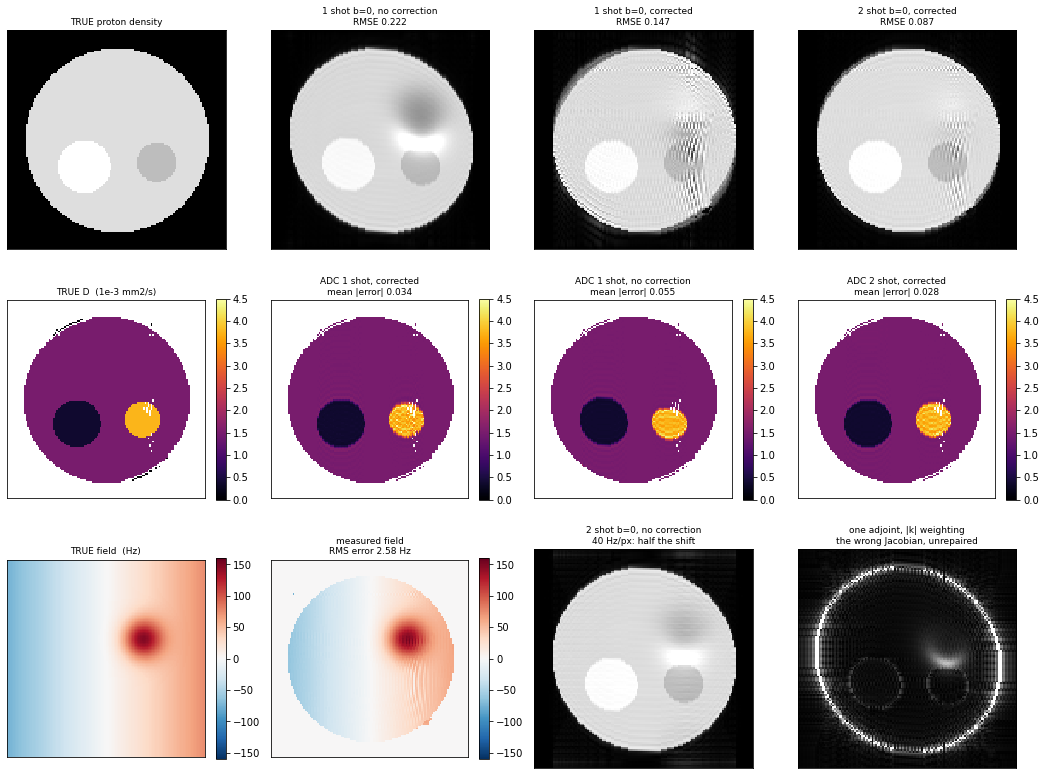

In [11]:
figure, axes = plt.subplots(3, 4, figsize=(14.5, 11.0))


def show(cell, image, title, **kwargs):
    handle = cell.imshow(image, interpolation='nearest', **kwargs)
    cell.set_title(title, fontsize=9)
    cell.set_xticks([])
    cell.set_yticks([])
    return handle


# --- row 0: proton density, and the b = 0 images -------------------------------------------------
grey = {'cmap': 'gray', 'vmin': 0.0, 'vmax': 1.0}


def normalised(image):
    '''Magnitude scaled by the least-squares fit to the truth, so the row shares one grey scale.'''
    magnitude = np.abs(image)
    flat, want = magnitude.ravel(), truth_pd_display.ravel()
    scale = float(flat @ want) / float(flat @ flat) if flat @ flat else 0.0
    return magnitude * scale


truth_pd_display = on_grid(maps['PD'], MATRIX)
truth_pd_display = truth_pd_display / truth_pd_display.max()
show(axes[0, 0], truth_pd_display, 'TRUE proton density', **grey)
show(axes[0, 1], normalised(uncorrected[1]['b0']),
     f'1 shot b=0, no correction\nRMSE {relative_rmse(uncorrected[1]["b0"], truth_pd_display):.3f}',
     **grey)
show(axes[0, 2], normalised(images[1]['b0']),
     f'1 shot b=0, corrected\nRMSE {relative_rmse(images[1]["b0"], truth_pd_display):.3f}', **grey)
show(axes[0, 3], normalised(images[2]['b0']),
     f'2 shot b=0, corrected\nRMSE {relative_rmse(images[2]["b0"], truth_pd_display):.3f}', **grey)

# --- row 1: diffusivity, and the ADC maps --------------------------------------------------------
hot = {'cmap': 'inferno', 'vmin': 0.0, 'vmax': 4.5}
figure.colorbar(show(axes[1, 0], np.where(mask, truth_d, np.nan), 'TRUE D  (1e-3 mm2/s)', **hot),
                ax=axes[1, 0], fraction=0.046)


def adc_error(measured):
    '''Mean |ADC - true D| over the mask, in the same units, for a like-for-like comparison.'''
    keep = mask & np.isfinite(measured)
    return float(np.nanmean(np.abs(measured[keep] - truth_d[keep])))


figure.colorbar(show(axes[1, 1], adc[1], f'ADC 1 shot, corrected\n'
                     f'mean |error| {adc_error(adc[1]):.3f}', **hot),
                ax=axes[1, 1], fraction=0.046)
figure.colorbar(show(axes[1, 2], adc_raw[1], f'ADC 1 shot, no correction\n'
                     f'mean |error| {adc_error(adc_raw[1]):.3f}', **hot),
                ax=axes[1, 2], fraction=0.046)
figure.colorbar(show(axes[1, 3], adc[2], f'ADC 2 shot, corrected\n'
                     f'mean |error| {adc_error(adc[2]):.3f}', **hot),
                ax=axes[1, 3], fraction=0.046)

# --- row 2: the field, and the two ways to get the reconstruction wrong --------------------------
field_scale = {'cmap': 'RdBu_r', 'vmin': -160, 'vmax': 160}
figure.colorbar(show(axes[2, 0], on_grid(b0_truth, B0_MATRIX), 'TRUE field  (Hz)', **field_scale),
                ax=axes[2, 0], fraction=0.046)
figure.colorbar(show(axes[2, 1], field_measured,
                     f'measured field\nRMS error {np.sqrt((error ** 2).mean()):.2f} Hz',
                     **field_scale),
                ax=axes[2, 1], fraction=0.046)
show(axes[2, 2], normalised(uncorrected[2]['b0']),
     f'2 shot b=0, no correction\n{scans[2]["pe_bandwidth_hz"]:.0f} Hz/px: half the shift', **grey)
show(axes[2, 3], normalised(adjoints['radial |k|']),
     'one adjoint, |k| weighting\nthe wrong Jacobian, unrepaired', **grey)

figure.tight_layout()
print('Row 0: the b=0 images are PD *times* T2 decay and coil weighting, so they are not meant to')
print('       equal the phantom -- the RMSE is there to be compared between them, not to zero.')
print('Row 1: ADC and true D are the same quantity, so these numbers should agree, and do.')
print('Row 2: the field the phantom has, the field the map recovered, and the two failure modes.')

## 8. On the scanner

- **Gradient delay is the first thing to measure.** A microsecond or two between the gradient and the
  ADC shifts the trajectory against the data, and on EPI it shows as a **Nyquist ghost** at half the
  FOV — the classic even/odd artefact, because the shift has opposite sign on reversed echoes. No
  field map explains it, and no amount of iteration removes it. Measure it and add it to `t_adc_s`;
  the reconstruction takes the trajectory as given, so the correction belongs there.
- **The field map's sign.** `angle(echo0 · conj(echo1))` is `+Δf`. Reconstruct once with the map and
  once with its negative and keep the sharper image; getting it backwards doubles the distortion
  rather than removing it, and the map looks perfectly reasonable either way.
- **Channel order and sample count** must match `sens` and the trajectory. A vendor reader may
  reorder or compress channels, and it may prepend dummy points; a sample count that disagrees with
  `readout.n_samples` is the first thing to check when an image comes out as noise.
- **Shot-to-shot phase.** This simulation has no motion, so the two shots of the segmented scan are
  mutually coherent. Real diffusion-weighted shots are not: bulk motion during the encoding puts a
  different phase on each, and pooling them without correcting it produces exactly the aliasing the
  pooling was meant to avoid. That is what phase navigators are for, and it is the reason single-shot
  EPI remains the default for DWI despite its distortion.
- **`SEQCRAFT_ASC_DIR`.** The build notebook's PNS number is synthetic unless you point it at a real
  descriptor. This sequence runs the readout at full slew.